In [10]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *
from scipy.special import gammaln
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


In [11]:
sgr_df = pickle.load(open('C:/Users/Emilien JEMELEN/Documents/SGR/CIFAR2/sgr_set2','rb')) 
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-2 dataset

(7000, 3)


,y_true,y_pred,SR
6500,0.0,0.0,0.929581
2944,0.0,0.0,0.982615
2024,1.0,1.0,0.542768
263,0.0,0.0,0.822609
4350,0.0,0.0,0.953512


In [12]:
delta = 0.001
desired_risks=[i/1000 for i in integers_log_spacing(5,300)]

## <font color = 'yellow'> 1. __0/1 loss__ 

#### <font color = 'violet'> 1.1. Risk coverage trade-offs

In [13]:
train_set = sgr_df.iloc[:int(len(sgr_df)/2)]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[int(len(sgr_df)/2):]

In [6]:
results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                       delta=delta, desired_risks=desired_risks, union = False)
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.017,0.014056,0.000000,0.139429,0.016736,0.136571
1,0.020,0.018028,0.001969,0.145143,0.016327,0.140000
2,0.022,0.021042,0.003781,0.151143,0.017408,0.147714
3,0.025,0.024136,0.009195,0.248571,0.020631,0.235429
4,0.028,0.028227,0.013000,0.285714,0.022340,0.268571
5,0.032,0.032829,0.017133,0.316857,0.021698,0.302857
6,0.037,0.037045,0.021138,0.351429,0.024639,0.336286
7,0.042,0.042198,0.026426,0.410857,0.033358,0.394000
8,0.048,0.048161,0.032337,0.468286,0.043505,0.459714
9,0.055,0.055134,0.039226,0.531714,0.045505,0.514857


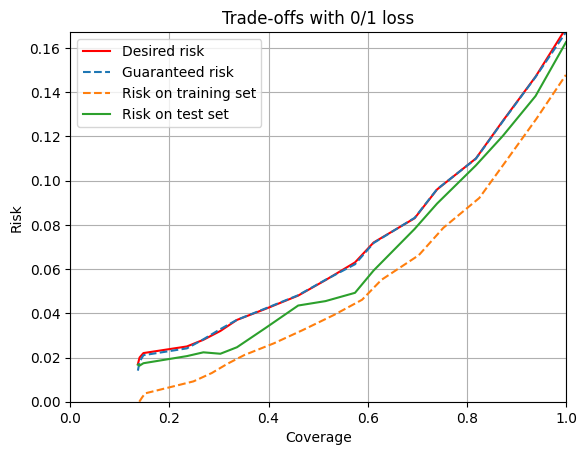

In [9]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with 0/1 loss')
plt.ylim(0,max(results.risk_bound))
plt.xlim(0,1)
plt.legend()
plt.grid()
plt.show()

__Comment__ : 

At 100% coverage one can observe 1- the classifier accuracy

#### <font color = 'violet'> 1.2. Evolution of trade-offs as class imbalance increases

In [8]:
sample_size = min(int(sgr_df.y_true.sum())*2, int((sgr_df.y_true==0).sum()))
all_propor_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(sgr_df, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=sample_size)

    train_set = imbalanced_set.iloc[:int(sample_size/2)]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[int(sample_size/2):]

    results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                           delta=delta, desired_risks=desired_risks, union = False)
    results['proportion_1'] = proportion_1/100
    all_propor_dfs = pd.concat([all_propor_dfs, results]).reset_index(drop=True)
    

all_propor_dfs

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.032,0.033524,0.013453,0.381849,0.013423,0.340183,0.01
1,0.037,0.037823,0.016973,0.403539,0.013740,0.373858,0.01
2,0.042,0.042908,0.020833,0.410959,0.015015,0.380137,0.01
3,0.048,0.049068,0.026829,0.468037,0.021053,0.433790,0.01
4,0.055,0.054676,0.031927,0.500571,0.025455,0.470890,0.01
...,...,...,...,...,...,...,...
810,0.169,0.169025,0.141266,0.973744,0.140258,0.972603,0.50
811,0.195,0.175861,0.148000,0.998858,0.151515,0.998288,0.50
812,0.225,0.175861,0.148000,0.998858,0.151515,0.998288,0.50
813,0.260,0.175861,0.148000,0.998858,0.151515,0.998288,0.50


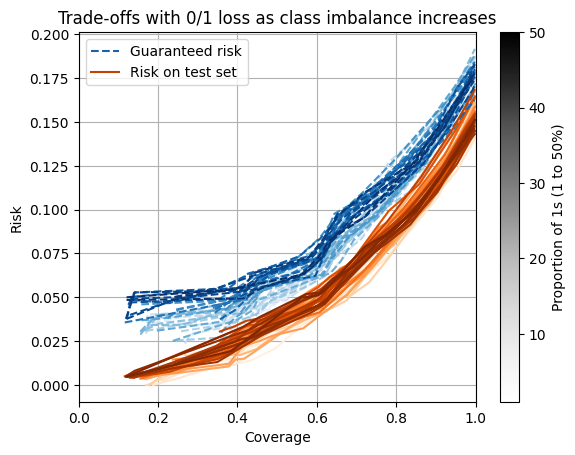

In [9]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')
cmap_gray = cm.get_cmap('Grays')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_propor_dfs.loc[all_propor_dfs.proportion_1 == proportion_1 / 100]

    line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue, linestyle='--')
    line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

    lines_guaranteed.append(line1)
    lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk', linestyle='--')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Proportion of 1s (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with 0/1 loss as class imbalance increases')
plt.grid()
plt.xlim(0, 1)
plt.show()

__Comment__ : here one can observe that
* the slope of risk-coverage curves does not really change along with class imbalance
* risk-coverage curves with high class imbalance are slightly offset with lower risk at fixed coverage : in other words, this classifier seems to commit less 0/1 errors when there are less 1s in the dataset (all other things being equal), which shows that this classifier commits relatively more misclassifications on 1s (FN) than on 0s (FP). => There is nothing general to observe : this offset may or may not be observed with other classifiers $f$ depending on their distribution of FP/FN among committed mistakes above confidence level $\theta^*$.

## <font color = 'yellow'> 2. __FP Detection loss__ (control over % of FPs)

#### <font color = 'violet'> 2.1. Risk coverage trade-offs

In [10]:
results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                       delta=delta, desired_risks=desired_risks, loss = 'FP', union = False)
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.032,0.037064,0.004082,0.139840,0.000000,0.140411
1,0.037,0.037441,0.017287,0.429224,0.008746,0.391553
2,0.042,0.041012,0.022660,0.579338,0.029970,0.571347
3,0.048,0.048523,0.029863,0.668950,0.037005,0.663242
4,0.055,0.055271,0.036293,0.739155,0.040593,0.731164
5,0.063,0.063663,0.044595,0.844749,0.044828,0.827626
6,0.072,0.071404,0.051680,0.883562,0.047151,0.871575
7,0.083,0.082550,0.062278,0.962329,0.061019,0.963470
8,0.096,0.089218,0.068571,0.998858,0.068611,0.998288
9,0.110,0.089218,0.068571,0.998858,0.068611,0.998288


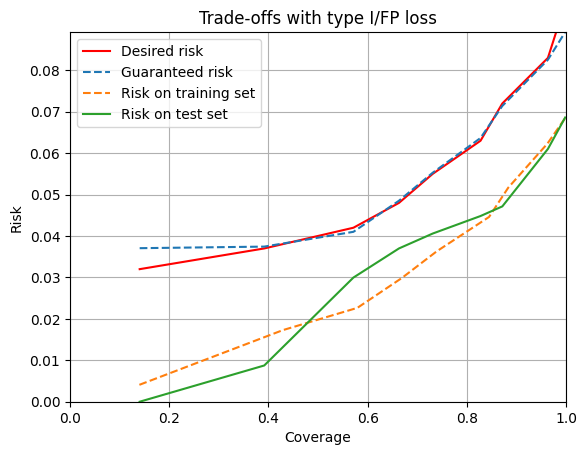

In [12]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.ylim(0,max(results.risk_bound))
plt.xlim(0,1)
plt.legend()
plt.title('Trade-offs with type I/FP loss')
plt.grid()
plt.show()

__Comment__ : ~threefold increase of performance at the cost of -80% coverage
1) Best guaranteed performance (left) is ~3% of samples classified as FPs, cost is coverage ~20%.
2) Baseline performance of classifier at 100% coverage would be ~10% of samples classified as FPs.

#### <font color = 'violet'> 2.2. Evolution of trade-offs as class imbalance increases

In [13]:
all_propor_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(sgr_df, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=sample_size)

    train_set = imbalanced_set.iloc[:int(sample_size/2)]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[int(sample_size/2):]

    results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                           delta=delta, desired_risks=desired_risks, loss='FP', union=False)
    results['proportion_1'] = proportion_1/100
    all_propor_dfs = pd.concat([all_propor_dfs, results]).reset_index(drop=True)
    
all_propor_dfs

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.032,0.033524,0.013453,0.381849,0.013423,0.340183,0.01
1,0.037,0.037823,0.016973,0.403539,0.013740,0.373858,0.01
2,0.042,0.042908,0.020833,0.410959,0.015015,0.380137,0.01
3,0.048,0.049068,0.026829,0.468037,0.021053,0.433790,0.01
4,0.055,0.054676,0.031927,0.500571,0.025455,0.470890,0.01
...,...,...,...,...,...,...,...
884,0.169,0.089218,0.068571,0.998858,0.068611,0.998288,0.50
885,0.195,0.089218,0.068571,0.998858,0.068611,0.998288,0.50
886,0.225,0.089218,0.068571,0.998858,0.068611,0.998288,0.50
887,0.260,0.089218,0.068571,0.998858,0.068611,0.998288,0.50


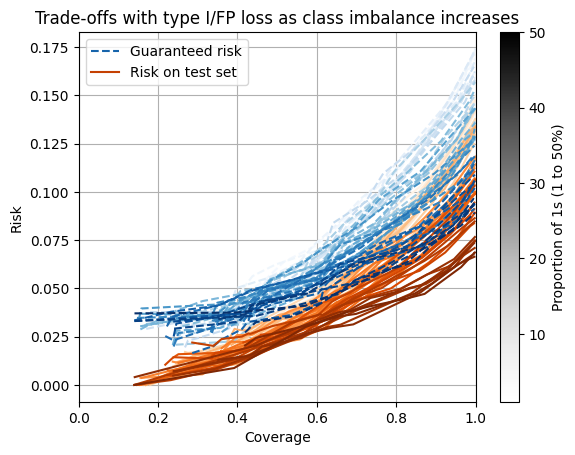

In [14]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')
cmap_gray = cm.get_cmap('Grays')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_propor_dfs.loc[all_propor_dfs.proportion_1 == proportion_1 / 100]

    line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue, linestyle='--')
    line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

    lines_guaranteed.append(line1)
    lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk', linestyle='--')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Proportion of 1s (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with type I/FP loss as class imbalance increases')
plt.grid()
plt.xlim(0, 1)
plt.show()

__Comment__ : one can observe that here less 1s means
* higher FP risk at fixed coverage (makes completely sense since classifier output does not change and there are relatively more 0s to commit mistakes on)
* steeper risk/coverage curves, ie stronger class imbalance => more FP risk improvement from the same amount of coverage renouncement

__In other words, in this setting, higher class imbalance => Selection with Guaranteed FP Risk brings more risk benefits with the same amount of coverage renouncement__

## <font color = 'yellow'> 3. __FN Detection loss__ (control over % of FNs)

#### <font color = 'violet'> 3.1. Risk coverage trade-offs

In [15]:
results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                       delta=delta, desired_risks=desired_risks, loss = 'FN', union=False)
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.037,0.037922,0.020408,0.587329,0.019724,0.578767
1,0.042,0.042141,0.024074,0.616438,0.020814,0.603311
2,0.048,0.047379,0.028546,0.639840,0.021759,0.629566
3,0.055,0.055611,0.035498,0.659247,0.027899,0.654680
4,0.063,0.062756,0.042683,0.748858,0.040990,0.738014
5,0.072,0.071735,0.051282,0.823630,0.050633,0.811644
6,0.083,0.082542,0.061674,0.906963,0.064127,0.898973
7,0.096,0.096550,0.074733,0.962329,0.077014,0.963470
8,0.110,0.101334,0.079429,0.998858,0.082905,0.998288
9,0.127,0.101334,0.079429,0.998858,0.082905,0.998288


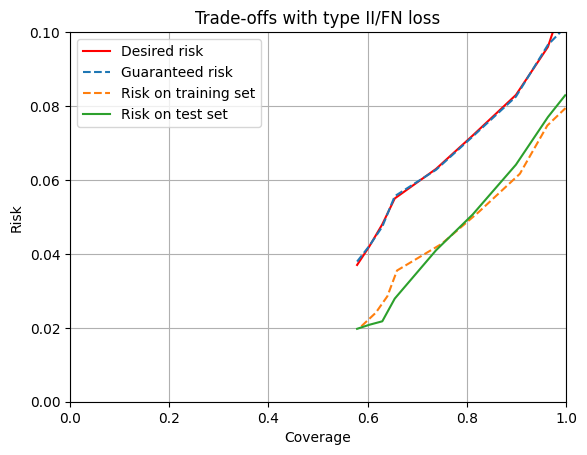

In [16]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.ylim(0,0.1)
plt.xlim(0,1)
plt.legend()
plt.title('Trade-offs with type II/FN loss')
plt.grid()
plt.show()

__Comment__ : threefold increase of performance at the cost of -40% coverage
1) Best guaranteed performance (left) is ~3% of samples classified as FNs, cost is coverage=60%.
2) Performance at 100% coverage would be 10% of samples classified as FNs.

#### <font color = 'violet'> 3.2. Evolution of trade-offs as class imbalance increases

In [17]:
all_propor_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(sgr_df, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=sample_size)

    train_set = imbalanced_set.iloc[:int(sample_size/2)]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[int(sample_size/2):]

    results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                           delta=delta, desired_risks=desired_risks, loss='FN', union=False)
    results['proportion_1'] = proportion_1/100
    all_propor_dfs = pd.concat([all_propor_dfs, results]).reset_index(drop=True)
    
all_propor_dfs

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.008,0.006399,0.001143,0.998858,0.000571,0.999429,0.01
1,0.009,0.006399,0.001143,0.998858,0.000571,0.999429,0.01
2,0.010,0.006399,0.001143,0.998858,0.000571,0.999429,0.01
3,0.011,0.006399,0.001143,0.998858,0.000571,0.999429,0.01
4,0.012,0.006399,0.001143,0.998858,0.000571,0.999429,0.01
...,...,...,...,...,...,...,...
1000,0.169,0.101334,0.079429,0.998858,0.082905,0.998288,0.50
1001,0.195,0.101334,0.079429,0.998858,0.082905,0.998288,0.50
1002,0.225,0.101334,0.079429,0.998858,0.082905,0.998288,0.50
1003,0.260,0.101334,0.079429,0.998858,0.082905,0.998288,0.50


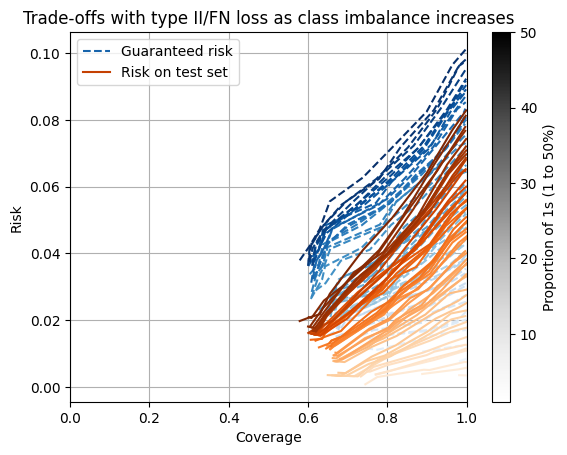

In [18]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')
cmap_gray = cm.get_cmap('Grays')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_propor_dfs.loc[all_propor_dfs.proportion_1 == proportion_1 / 100]

    line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue, linestyle='--')
    line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

    lines_guaranteed.append(line1)
    lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk', linestyle='--')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Proportion of 1s (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with type II/FN loss as class imbalance increases')
plt.grid()
plt.xlim(0, 1)
#plt.ylim(0, 0.1)

plt.show()

__Comment__ : one can observe that here less 1s means
* lower FN risk at fixed coverage (makes completely sense since classifier output does not change and there are relatively less 1s to commit mistakes on)
* flatter risk/coverage curves, ie stronger class imbalance => less FN risk improvement from the same amount of coverage renouncement

__In other words, in this setting, higher class imbalance => Selection with Guaranteed FN Risk brings less risk benefits with the same amount of coverage renouncement__